# Piloto 2026 · recalibración de aromas con rCO₂ liberado

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "fermentation_model").exists():
    ROOT = ROOT.parent
if not (ROOT / "fermentation_model").exists():
    raise RuntimeError("Execute from the repository or a descendant directory")
import os
sys.path.insert(0, str(ROOT / "fermentation_model"))
from pilot_2026 import run_aroma_co2_release_recalibration_2026 as analysis
result = analysis.load_results() if os.environ.get("PILOT_AROMA_REUSE_RESULTS") == "1" else analysis.run_analysis()
print("Resultados:", analysis.RESULTS_DIR.relative_to(ROOT))

Resultados: fermentation_model\pilot_2026\results\aroma_co2_release_recalibration_2026


## tl;dr

In [2]:
summary = result["summary"]
display(summary["holdout_wine_rmse_comparison"])
print("Mediana CO2 liberado / estequiométrico integrado:", round(summary["median_released_over_stoichiometric_integral"], 4))
print("Pérdida identificada:", summary["loss_identified_with_released_co2"])
print("Gate:", result["gate"]["verdict"])

{'ethyl_acetate': {'released_rmse_ug_l': 5547.466871940997,
  'legacy_rmse_ug_l': 5546.25486737408,
  'relative_change': 0.00021852666274800386},
 'ethyl_octanoate': {'released_rmse_ug_l': 48.41261647600324,
  'legacy_rmse_ug_l': 48.345092115226365,
  'relative_change': 0.0013967159399744977},
 'isoamyl_acetate': {'released_rmse_ug_l': 723.3509589325366,
  'legacy_rmse_ug_l': 723.4027276972986,
  'relative_change': -7.156285534994796e-05}}

Mediana CO2 liberado / estequiométrico integrado: 1.8159
Pérdida identificada: {'ethyl_acetate': False, 'ethyl_octanoate': True, 'isoamyl_acetate': True}
Gate: PASS_CONDITIONAL


## Contexto y métodos

- Se conservan formación aromática, partición UNIFAC, captura, errores y censura del modelo anterior.
- Se sustituye rCO₂ estequiométrico por rCO₂ emitido predicho por `solubility_o2_nitrogen_boost_continuous_release`.
- El forcing usa parámetros CO₂ específicos de lote y la ganancia de matriz validada.
- `26158` y `26211` son holdouts tanto para CO₂ como para aromas.
- La primera muestra de vino inicializa la trayectoria y no entra al RMSE de validación; las muestras siguientes sí.
- Se reestima `effective_loss_scale`: su valor absoluto depende de la escala del forcing rCO₂.

## Datos y forcing rCO₂

,source,experiment_id,matrix,role,integrated_rco2_g_l,peak_rco2_g_l_h,released_over_stoichiometric_integral
0,released_co2_model,26157,pilot_lot2,calibration,66.8270,0.7554,1.9264
1,released_co2_model,26158,pilot_lot2,holdout,64.3016,0.7475,1.9048
2,released_co2_model,26159,pilot_lot2,calibration,64.1903,0.6822,1.8218
3,released_co2_model,26210,pilot_lot3,calibration,62.7746,0.9241,1.8100
4,released_co2_model,26211,pilot_lot3,holdout,63.2467,0.9410,1.7825
5,released_co2_model,26212,pilot_lot3,calibration,61.9066,1.0544,1.7432
6,stoichiometric_legacy,26157,pilot_lot2,calibration,34.6909,0.4286,1.9264
7,stoichiometric_legacy,26158,pilot_lot2,holdout,33.7572,0.4337,1.9048
8,stoichiometric_legacy,26159,pilot_lot2,calibration,35.2351,0.4051,1.8218
9,stoichiometric_legacy,26210,pilot_lot3,calibration,34.6827,0.5158,1.8100


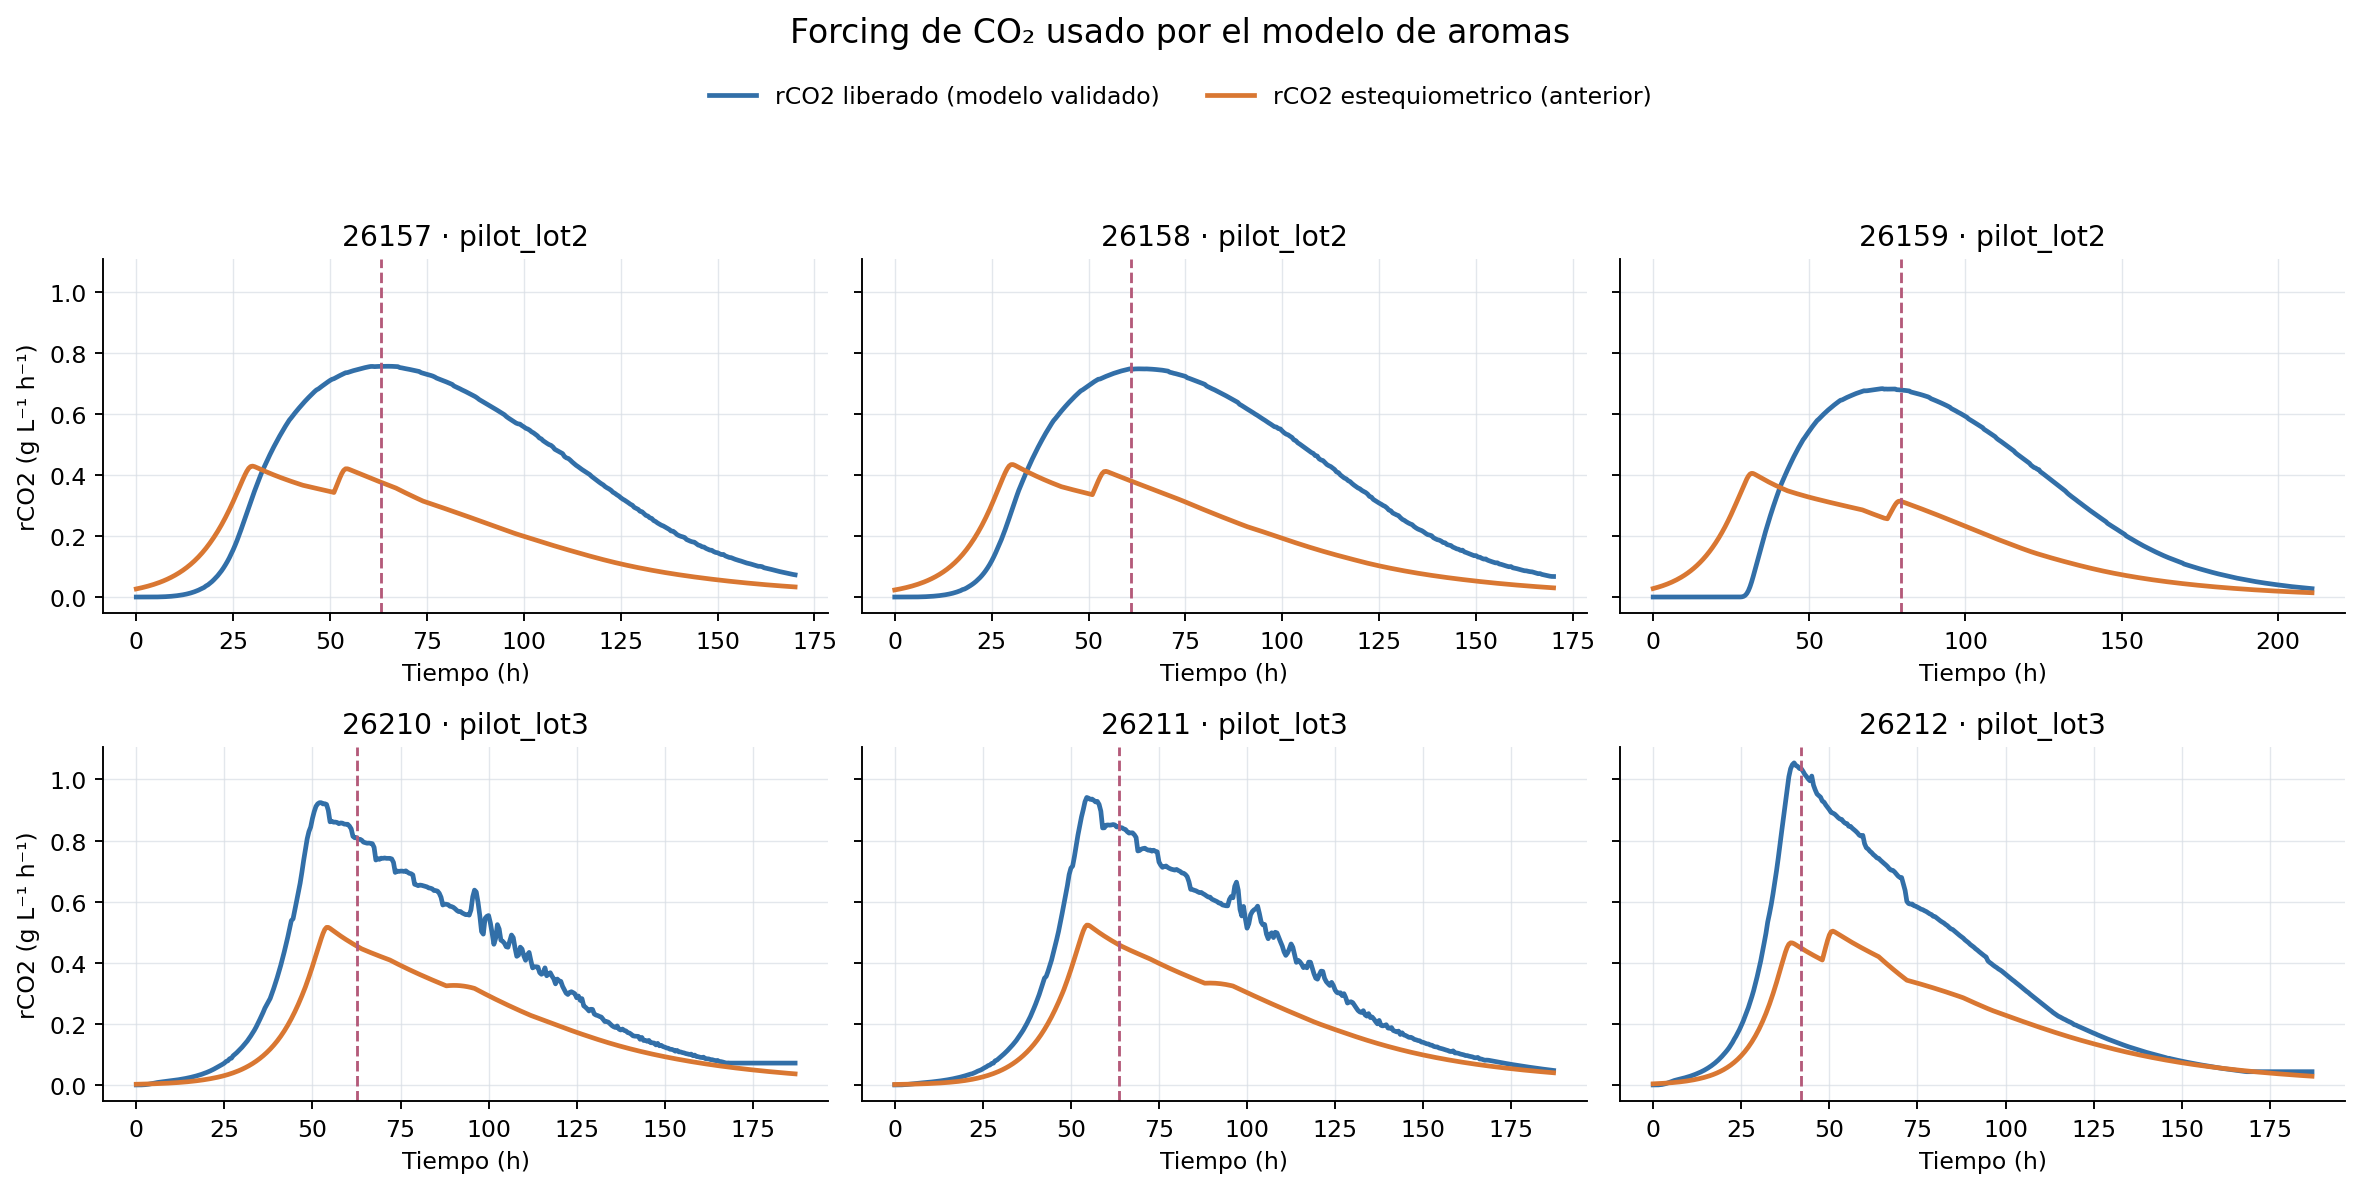

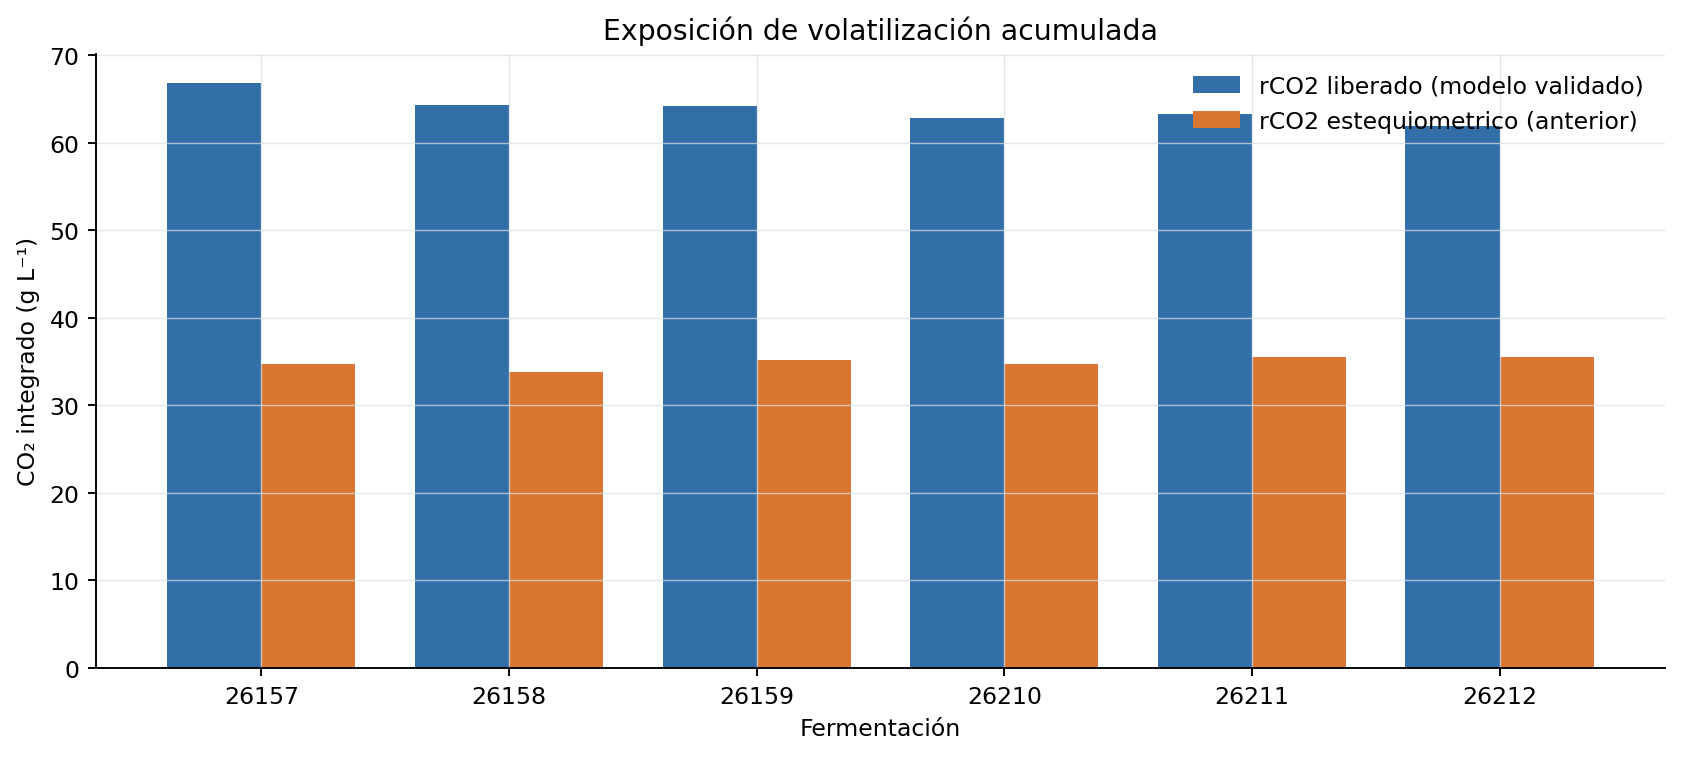

In [3]:
display(result["exposure"].round(4))
display(Image(filename=analysis.FIGURE_DIR / "rco2_forcing_comparison.png"))
display(Image(filename=analysis.FIGURE_DIR / "integrated_rco2_exposure.png"))

## Resultados de calibración y validación

,forcing_source,fit_scope,species,parameter,estimate,lower_bound,upper_bound,active_bound,std_log_local
9,released_co2_model,all_data,ethyl_acetate,formation_growth_ug_per_g_sugar,42.32429,0.00010,10000.0,False,0.58959
10,released_co2_model,all_data,ethyl_acetate,formation_stationary_ug_per_g_sugar,72.61772,0.00010,10000.0,False,0.08749
11,released_co2_model,all_data,ethyl_acetate,effective_loss_scale,0.00770,0.00001,10.0,False,0.11758
12,released_co2_model,all_data,ethyl_octanoate,formation_growth_ug_per_g_sugar,0.15111,0.00010,10000.0,False,2.49458
13,released_co2_model,all_data,ethyl_octanoate,formation_stationary_ug_per_g_sugar,0.55158,0.00010,10000.0,False,0.18112
14,released_co2_model,all_data,ethyl_octanoate,effective_loss_scale,0.00926,0.00001,10.0,False,0.14800
15,released_co2_model,all_data,isoamyl_acetate,formation_growth_ug_per_g_sugar,0.40205,0.00010,10000.0,False,4.67123
16,released_co2_model,all_data,isoamyl_acetate,formation_stationary_ug_per_g_sugar,7.08258,0.00010,10000.0,False,0.11433
17,released_co2_model,all_data,isoamyl_acetate,effective_loss_scale,0.00734,0.00001,10.0,False,0.07788
27,stoichiometric_legacy,all_data,ethyl_acetate,formation_growth_ug_per_g_sugar,42.18190,0.00010,10000.0,False,0.59092


,forcing_source,fit_scope,species,role,domain,n_observed_scored,observed_mean,rmse,nrmse_over_mean,mae,bias,n_censored,censor_compliance_fraction
7,released_co2_model,calibration_only,ethyl_acetate,holdout,wine,11,11378.9113,5547.4669,0.4875,3271.9710,-2600.6706,0,NaN
9,released_co2_model,calibration_only,ethyl_octanoate,holdout,wine,11,79.7833,48.4126,0.6068,26.8755,-20.9541,0,NaN
11,released_co2_model,calibration_only,isoamyl_acetate,holdout,wine,11,1099.0934,723.3510,0.6581,499.5256,-423.6449,2,1.0
19,stoichiometric_legacy,calibration_only,ethyl_acetate,holdout,wine,11,11378.9113,5546.2549,0.4874,3270.4771,-2598.5970,0,NaN
21,stoichiometric_legacy,calibration_only,ethyl_octanoate,holdout,wine,11,79.7833,48.3451,0.6060,26.8304,-20.8017,0,NaN
23,stoichiometric_legacy,calibration_only,isoamyl_acetate,holdout,wine,11,1099.0934,723.4027,0.6582,499.5124,-423.7558,2,1.0
31,released_co2_model,calibration_only,ethyl_acetate,holdout,condensate,0,NaN,NaN,NaN,NaN,NaN,11,1.0
33,released_co2_model,calibration_only,ethyl_octanoate,holdout,condensate,8,522.5388,846.0720,1.6192,517.6462,-517.6462,3,1.0
35,released_co2_model,calibration_only,isoamyl_acetate,holdout,condensate,6,2364.4711,3074.9179,1.3005,2317.2015,-2317.2015,5,1.0
43,stoichiometric_legacy,calibration_only,ethyl_acetate,holdout,condensate,0,NaN,NaN,NaN,NaN,NaN,11,1.0


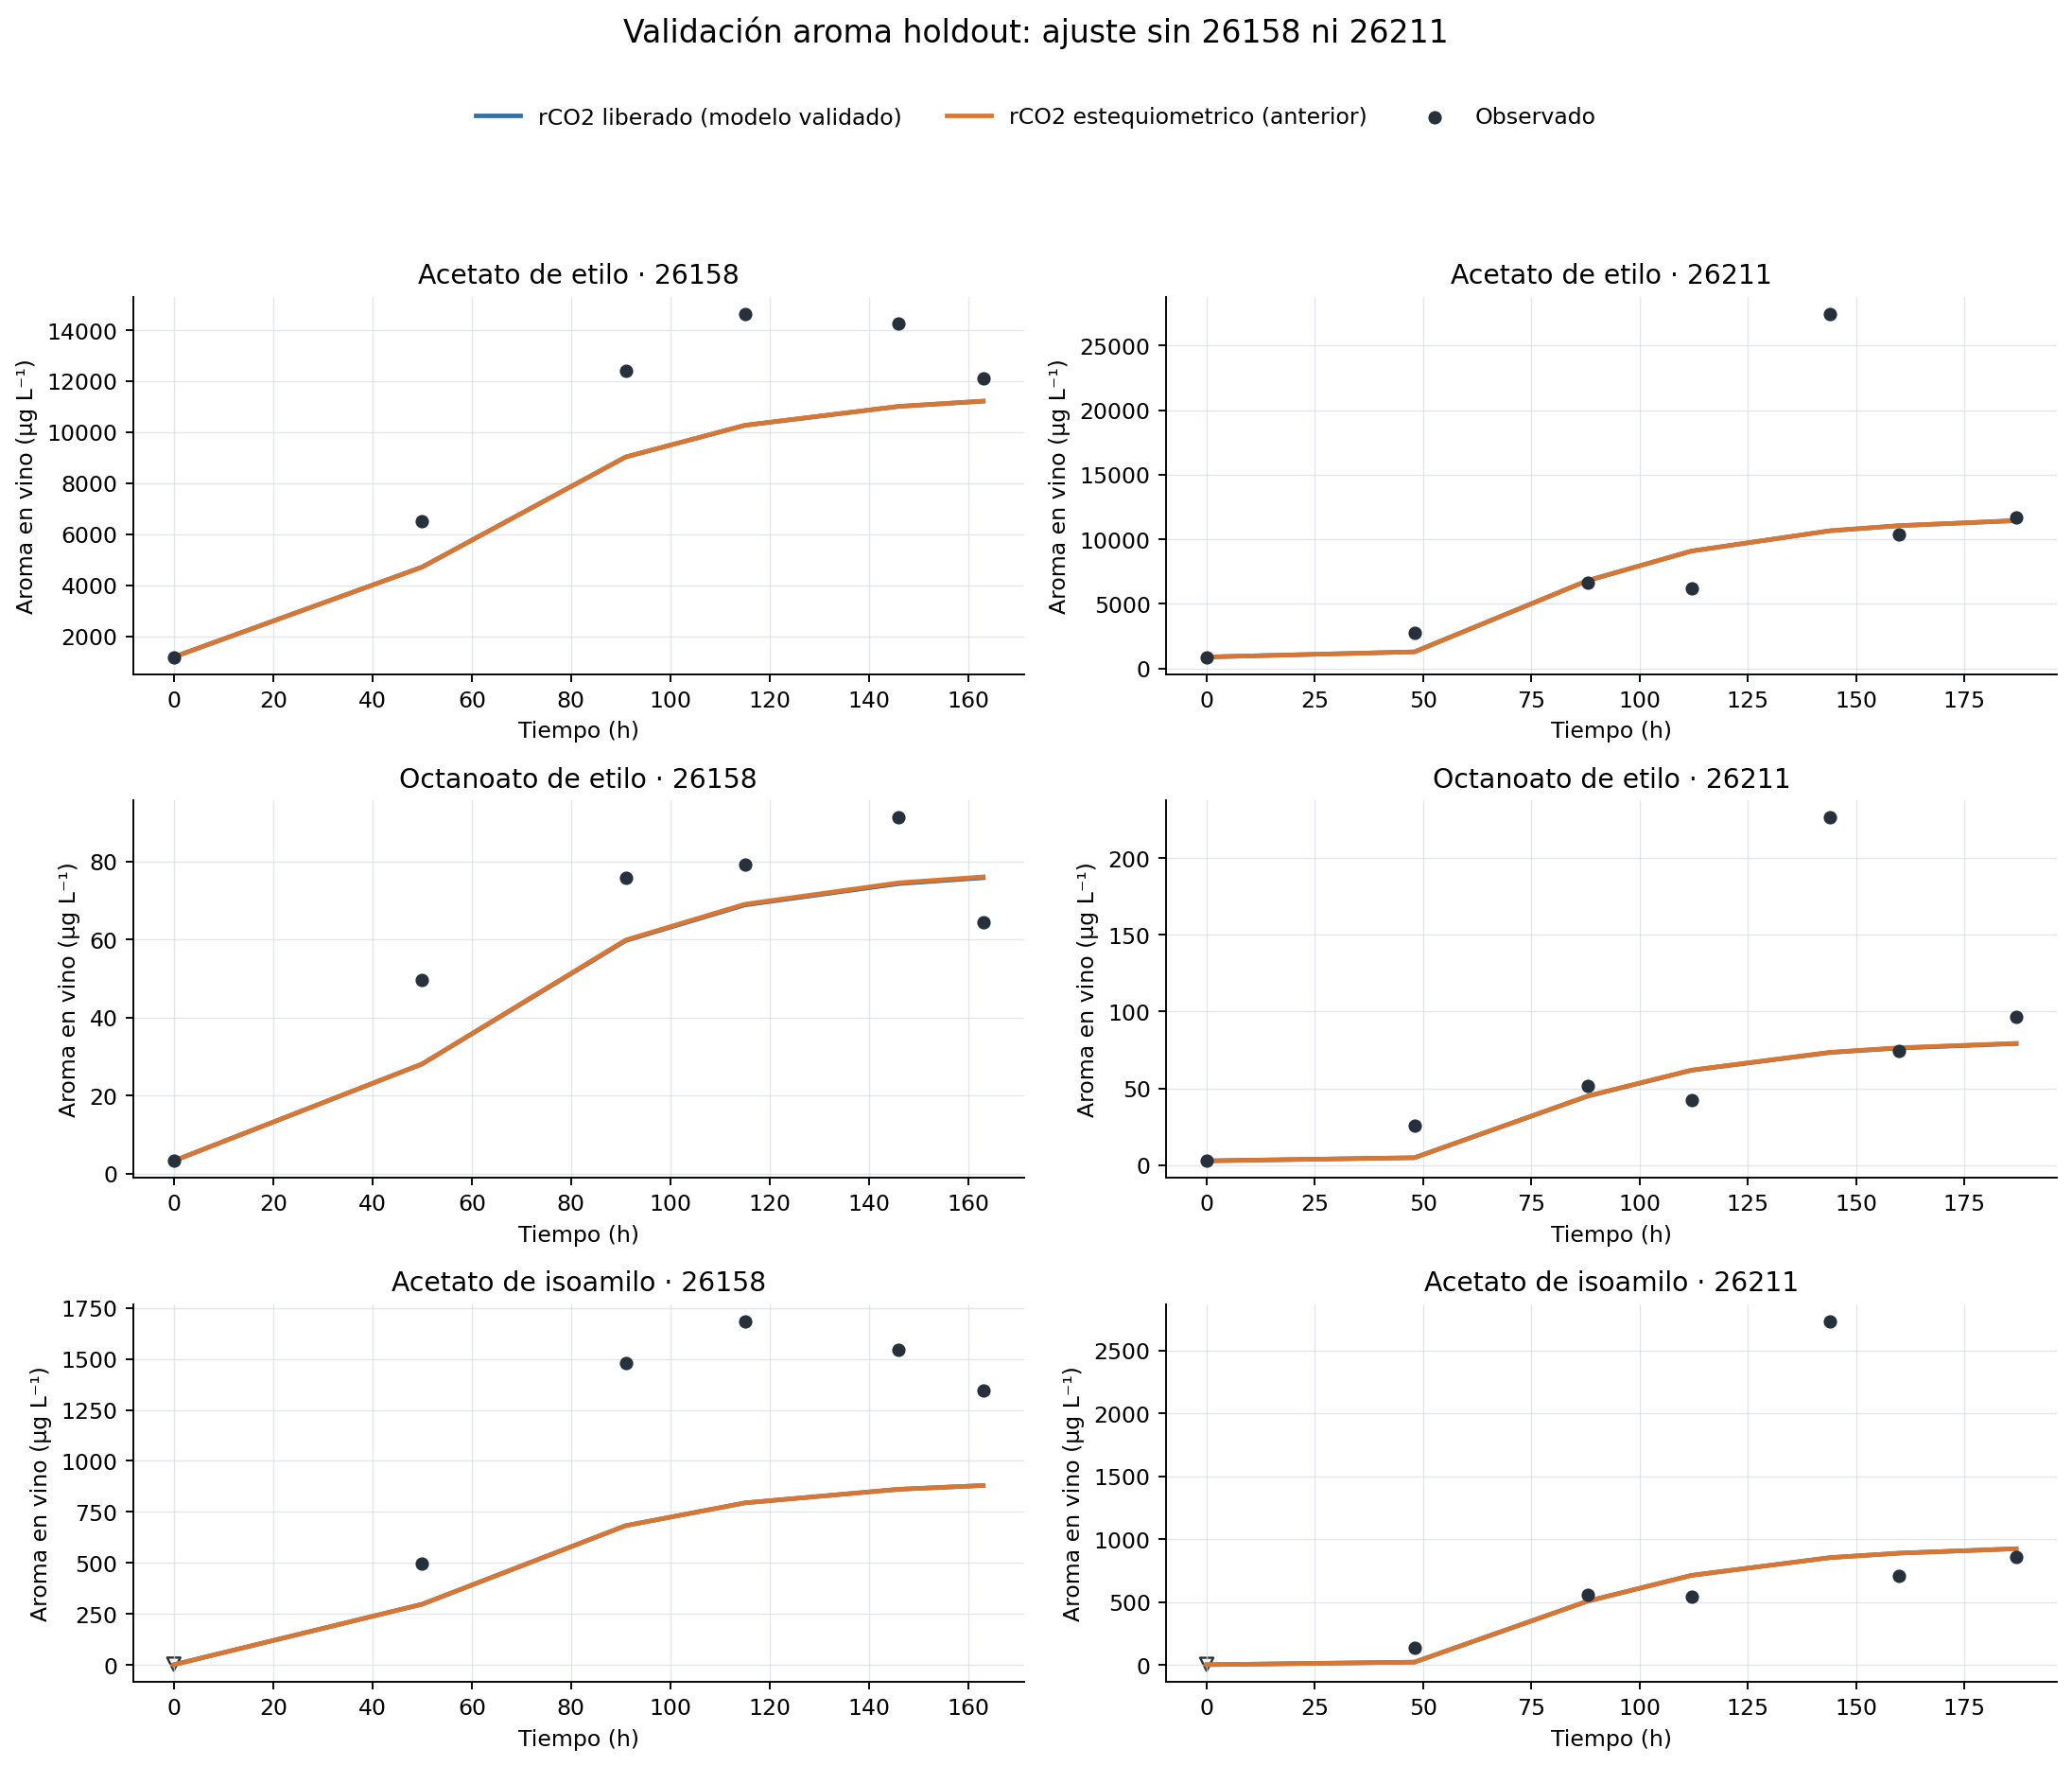

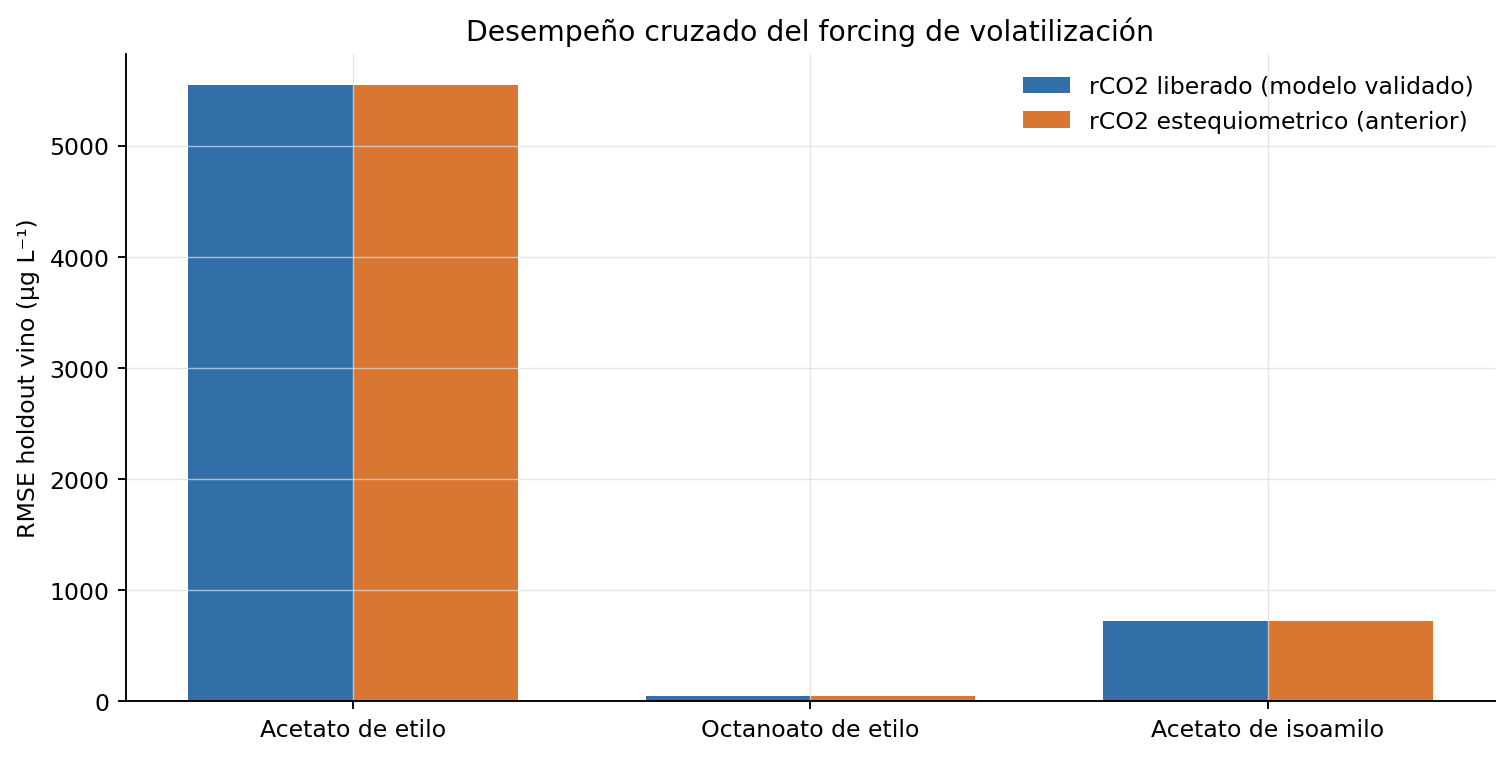

In [4]:
display(result["parameters"].query("fit_scope == 'all_data'").round(5))
display(result["metrics"].query("fit_scope == 'calibration_only' and role == 'holdout'").round(4))
display(Image(filename=analysis.FIGURE_DIR / "holdout_wine_predictions.png"))
display(Image(filename=analysis.FIGURE_DIR / "holdout_wine_rmse_comparison.png"))

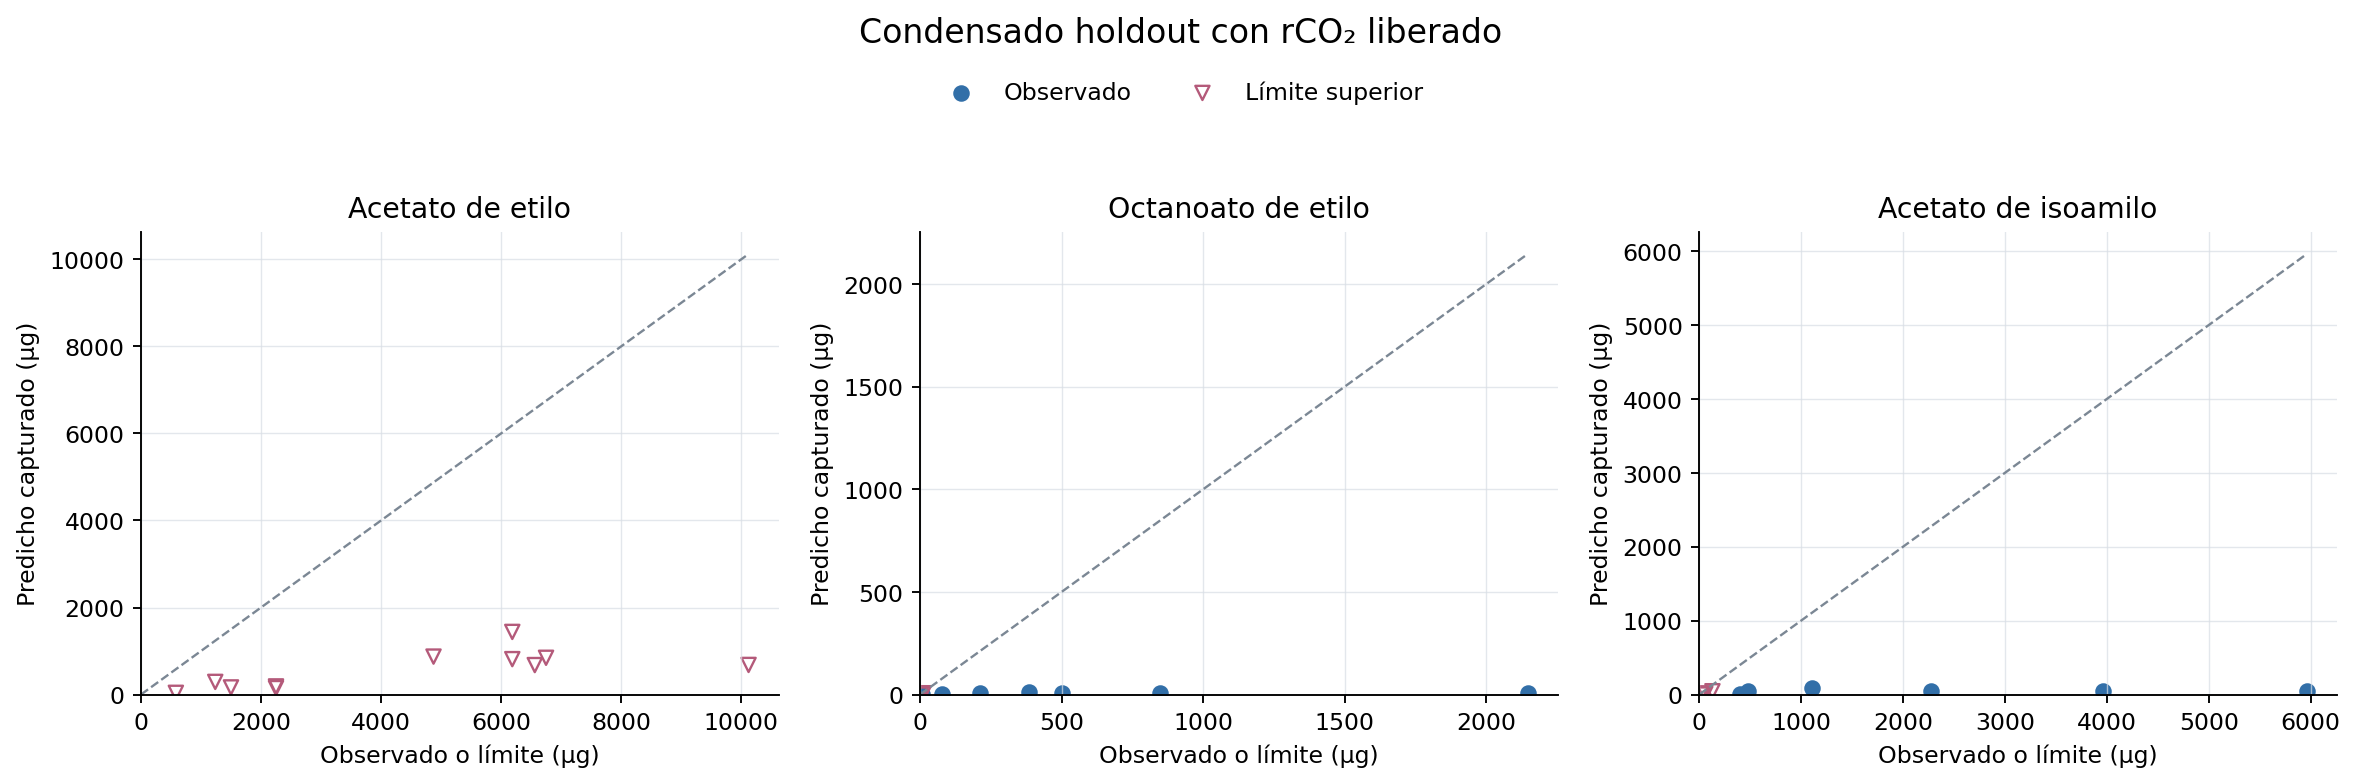

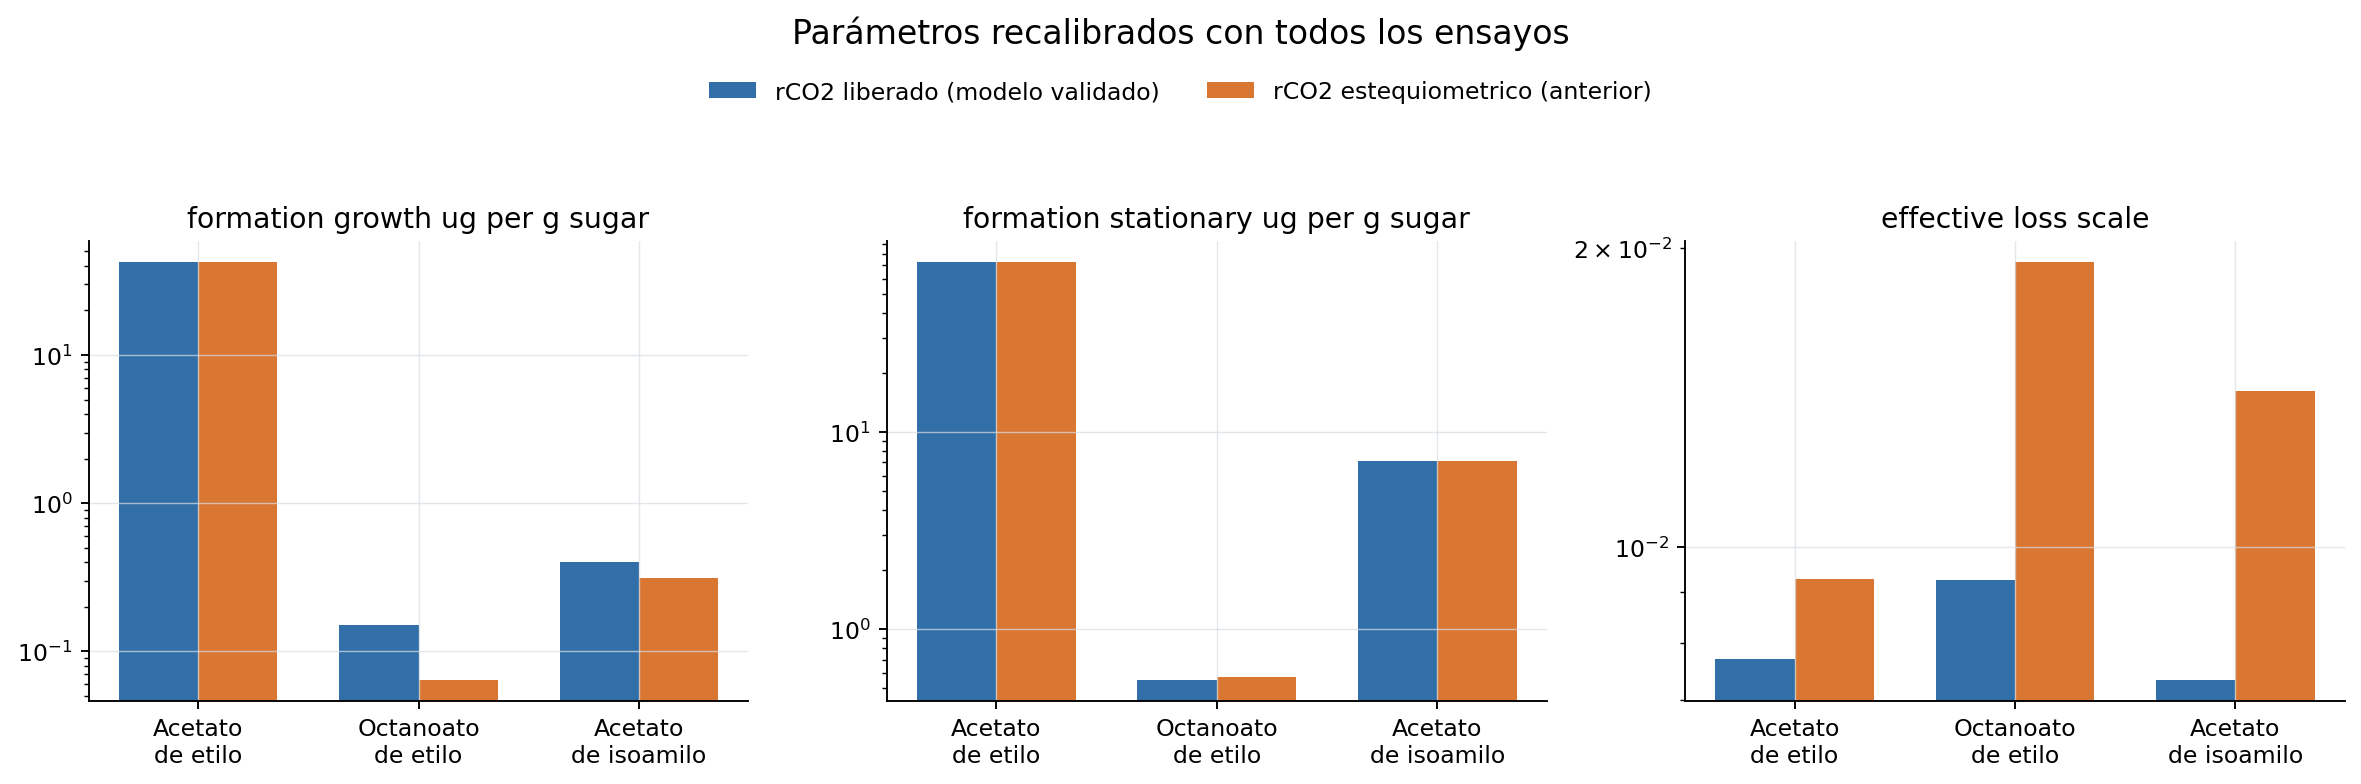

In [5]:
display(Image(filename=analysis.FIGURE_DIR / "holdout_condensate_predictions.png"))
display(Image(filename=analysis.FIGURE_DIR / "aroma_parameter_comparison.png"))

## Identificabilidad

,forcing_source,fit_scope,species,objective,objective_per_observation,active_bound_fraction,loss_separately_identified,weak_parameters
3,released_co2_model,all_data,ethyl_acetate,72.2842,1.0039,0.0,False,formation_growth_ug_per_g_sugar;effective_loss...
4,released_co2_model,all_data,ethyl_octanoate,384.6791,5.3428,0.0,True,formation_growth_ug_per_g_sugar
5,released_co2_model,all_data,isoamyl_acetate,369.2797,5.1289,0.0,True,formation_growth_ug_per_g_sugar


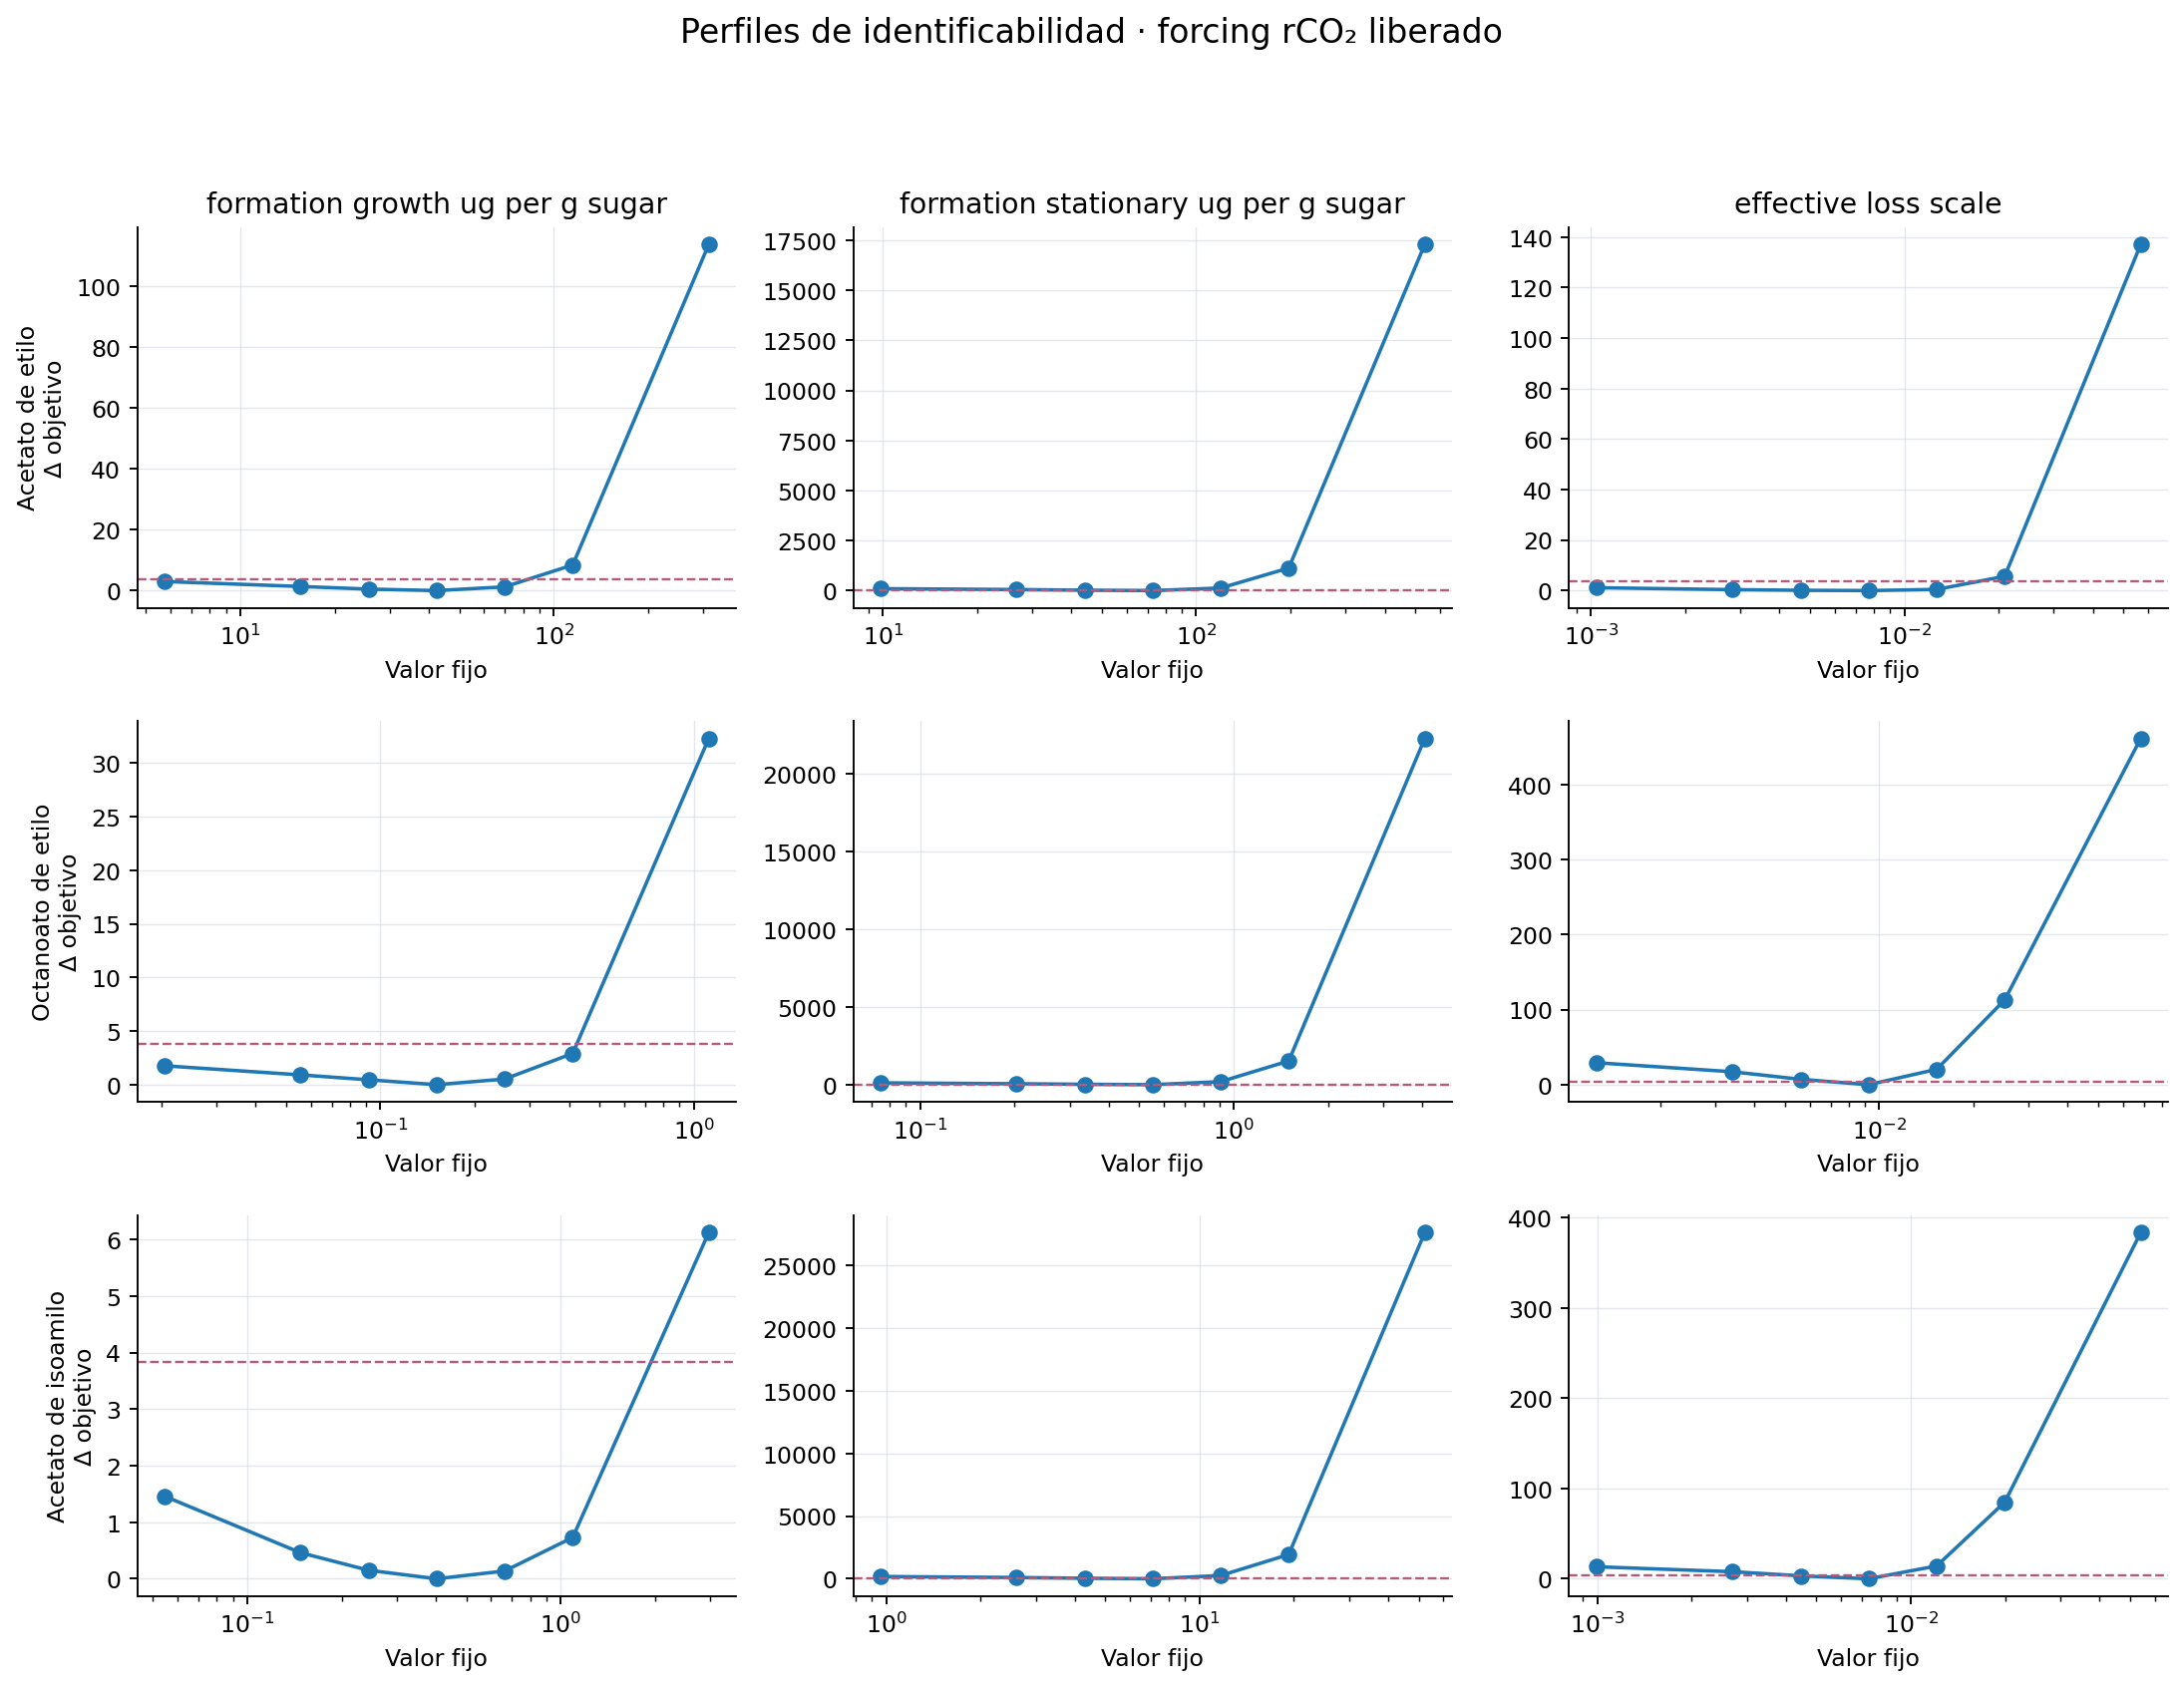

In [6]:
display(result["validation"].query("forcing_source == 'released_co2_model' and fit_scope == 'all_data'").round(4))
display(Image(filename=analysis.FIGURE_DIR / "release_forcing_profile_likelihood.png"))

## Takeaways

La comparación relevante es el desempeño holdout después de volver a estimar la escala de pérdida para cada definición de rCO₂. Una mejora del forcing no implica por sí sola identificabilidad completa: `effective_loss_scale` sigue siendo condicional a la curva de CO₂ fijada y a la información disponible en condensados. Los límites de detección se incorporan como censura, no como ceros.

In [7]:
print("Notebook ejecutado sin errores.")
print("Figuras embebidas:", len(result["figures"]))
print("Artefactos:", analysis.RESULTS_DIR.relative_to(ROOT))

Notebook ejecutado sin errores.
Figuras embebidas: 7
Artefactos: fermentation_model\pilot_2026\results\aroma_co2_release_recalibration_2026
